# Portfolio Objective Investigation

**Problem**: During DPO training on portfolio, the logged training objective (and regret) 
*worsens* over epochs, even while the training loss decreases.

## Background

Portfolio objective: $f(\theta^*, z) = {\theta^*}^\top z - \alpha \, z^\top \Sigma z$  
This is **maximized** by the solver. Higher = better portfolio.

## Key distinction: two different evaluation paths

| Quantity | How it's computed | Decision used |
|---|---|---|
| **Training loss** (backprop) | `perturbed.forward()` → `perturbedSoftDecision` → `get_objective(θ*, z̄)` | **Soft decision** z̄ = E[z(θ̂+σε)] |
| **Logged `obj`** (CSV) | `print_metrics()` → `get_decision(θ̂, isTrain=False)` → `get_objective(θ*, z(θ̂))` | **Hard re-solve** z(θ̂) |
| **Logged `eval`** (regret) | `regret_func()` → \|f(θ\*, z(θ̂)) - f(θ\*, z\*)\| | **Hard re-solve** z(θ̂) |
| **Logged `loss`** | `print_metrics()` → `loss_fn(θ̂, θ*, ...)` under `no_grad` | **Soft decision** z̄ |

So **loss uses the soft decision** z̄ while **obj/eval use hard re-solved decisions** z(θ̂).

## The puzzle

Loss ↓ means the soft-decision regret |f(θ\*, z̄) − f(θ\*, z\*)| is shrinking.  
But obj ↓ (more negative) means f(θ\*, z(θ̂)) is getting **worse** — the model's predicted
coefficients produce worse hard portfolio allocations.

This notebook investigates **why** and **how bad** the divergence is.

In [1]:
import os, re, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
os.chdir(PROJECT_ROOT)
print(f"Working directory: {os.getcwd()}")

SIGMAS = {"005": 0.05, "01": 0.1, "05": 0.5}
LRS = {"lr1e3": 1e-3, "lr5e3": 5e-3, "lr1e2": 1e-2}

def read_traces(prefix):
    base = f"saved_records/portfolio-real/perturb/{prefix}"
    tcsv = os.path.join(base, "train_logs.csv")
    vcsv = os.path.join(base, "val_logs.csv")
    if not os.path.exists(tcsv):
        return None, None
    tdf = pd.read_csv(tcsv)
    vdf = pd.read_csv(vcsv)
    tdf["epoch_num"] = tdf["epoch"].str.extract(r"(\d+)").astype(int)
    vdf["epoch_num"] = vdf["epoch"].str.extract(r"(\d+)").astype(int)
    return tdf, vdf

Working directory: /cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark


## 1. Overview: All 9 configs — obj, loss, eval over epochs

For every (σ, lr) combo, show how obj/loss/eval evolve.

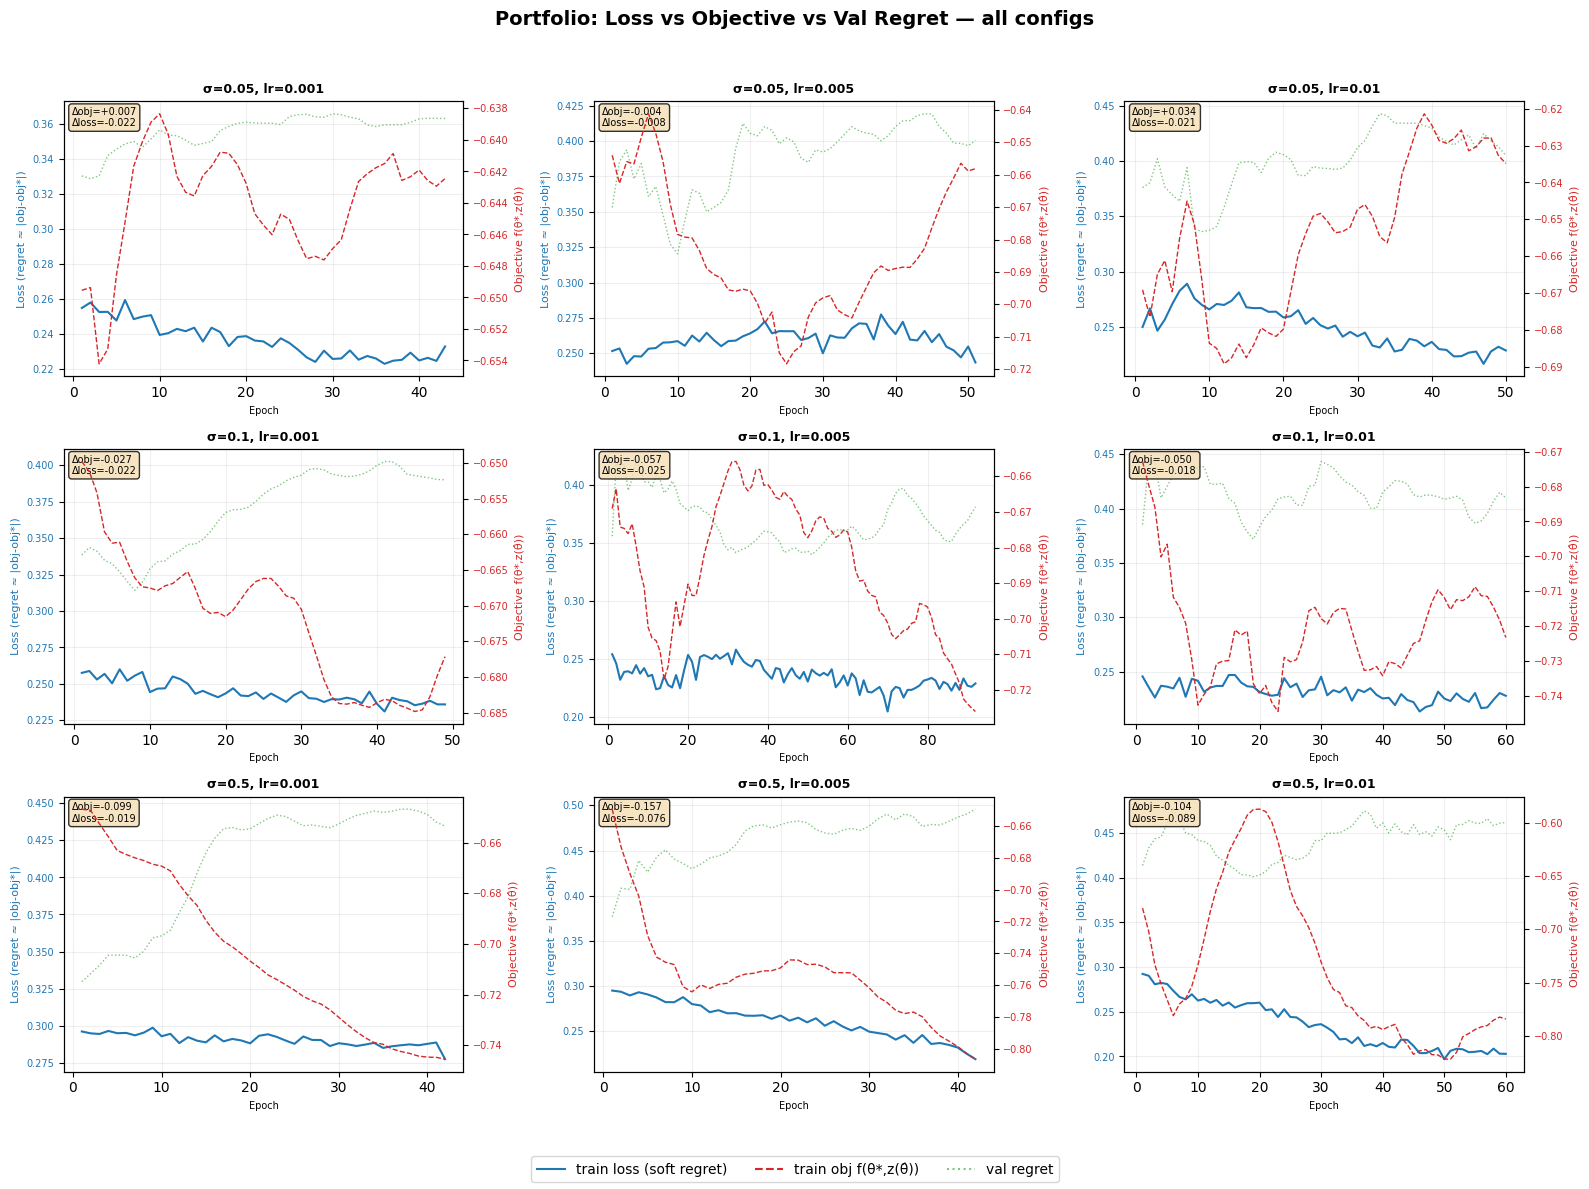

In [2]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=False)

for i, (sigma_tag, sigma_val) in enumerate(SIGMAS.items()):
    for j, (lr_tag, lr_val) in enumerate(LRS.items()):
        prefix = f"sd1_s{sigma_tag}_{lr_tag}"
        tdf, vdf = read_traces(prefix)
        ax = axes[i, j]
        if tdf is None:
            ax.set_title(f"σ={sigma_val}, lr={lr_val}\n(no data)")
            ax.axis("off")
            continue
        
        # Plot loss on left axis
        color_loss = "tab:blue"
        ax.plot(tdf["epoch_num"], tdf["loss"], color=color_loss, label="train loss", linewidth=1.5)
        ax.set_ylabel("Loss (regret ≈ |obj-obj*|)", color=color_loss, fontsize=8)
        ax.tick_params(axis="y", labelcolor=color_loss, labelsize=7)
        
        # Plot obj on right axis
        ax2 = ax.twinx()
        color_obj = "tab:red"
        ax2.plot(tdf["epoch_num"], tdf["obj"], color=color_obj, linestyle="--", label="train obj", linewidth=1)
        ax2.set_ylabel("Objective f(θ*,z(θ̂))", color=color_obj, fontsize=8)
        ax2.tick_params(axis="y", labelcolor=color_obj, labelsize=7)
        
        # Also show val regret
        ax.plot(vdf["epoch_num"], vdf["eval"], color="tab:green", alpha=0.6,
                linestyle=":", label="val regret", linewidth=1)
        
        ax.set_title(f"σ={sigma_val}, lr={lr_val}", fontsize=9, fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=7)
        ax.grid(True, alpha=0.2)
        
        # Annotate direction of change
        obj_delta = tdf["obj"].iloc[-1] - tdf["obj"].iloc[0]
        loss_delta = tdf["loss"].iloc[-1] - tdf["loss"].iloc[0]
        ax.text(0.02, 0.98, f"Δobj={obj_delta:+.3f}\nΔloss={loss_delta:+.3f}",
                transform=ax.transAxes, fontsize=7, va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.8))

# Shared legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="tab:blue", label="train loss (soft regret)"),
    Line2D([0], [0], color="tab:red", linestyle="--", label="train obj f(θ*,z(θ̂))"),
    Line2D([0], [0], color="tab:green", linestyle=":", alpha=0.6, label="val regret"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=10)
fig.suptitle("Portfolio: Loss vs Objective vs Val Regret — all configs",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

## 2. Quantify the divergence: Δobj vs Δloss across all configs

In [3]:
rows = []
for sigma_tag, sigma_val in SIGMAS.items():
    for lr_tag, lr_val in LRS.items():
        prefix = f"sd1_s{sigma_tag}_{lr_tag}"
        tdf, vdf = read_traces(prefix)
        if tdf is None:
            continue
        rows.append({
            "sigma": sigma_val,
            "lr": lr_val,
            "config": f"σ={sigma_val}, lr={lr_val}",
            "n_epochs": len(tdf),
            "obj_start": tdf["obj"].iloc[0],
            "obj_end": tdf["obj"].iloc[-1],
            "obj_delta": tdf["obj"].iloc[-1] - tdf["obj"].iloc[0],
            "loss_start": tdf["loss"].iloc[0],
            "loss_end": tdf["loss"].iloc[-1],
            "loss_delta": tdf["loss"].iloc[-1] - tdf["loss"].iloc[0],
            "val_regret_start": vdf["eval"].iloc[0],
            "val_regret_best": vdf["eval"].min(),
            "val_regret_end": vdf["eval"].iloc[-1],
            "pred_loss_start": tdf["pred_loss"].iloc[0],
            "pred_loss_end": tdf["pred_loss"].iloc[-1],
        })

summary = pd.DataFrame(rows)
summary["obj_worsened"] = summary["obj_delta"] < 0  # more negative = worse for maximization
summary["loss_improved"] = summary["loss_delta"] < 0

print("Configuration Summary")
print("=" * 100)
display_cols = ["config", "n_epochs", "obj_delta", "loss_delta", 
                "val_regret_best", "pred_loss_start", "pred_loss_end", 
                "obj_worsened", "loss_improved"]
print(summary[display_cols].to_string(index=False))

n_both = ((summary["obj_worsened"]) & (summary["loss_improved"])).sum()
print(f"\nConfigs where loss improved but objective worsened: {n_both}/{len(summary)}")
print(f"Configs where objective worsened: {summary['obj_worsened'].sum()}/{len(summary)}")

Configuration Summary
          config  n_epochs  obj_delta  loss_delta  val_regret_best  pred_loss_start  pred_loss_end  obj_worsened  loss_improved
σ=0.05, lr=0.001        43   0.007094   -0.022017         0.328793         0.026331       0.033495         False           True
σ=0.05, lr=0.005        51  -0.004135   -0.008087         0.320383         0.028655       0.126473          True           True
 σ=0.05, lr=0.01        50   0.034286   -0.021225         0.336216         0.035334       0.441744         False           True
 σ=0.1, lr=0.001        49  -0.027337   -0.021622         0.314225         0.026288       0.043768          True           True
 σ=0.1, lr=0.005        92  -0.056984   -0.025236         0.340088         0.028397       0.219860          True           True
  σ=0.1, lr=0.01        60  -0.050493   -0.017839         0.372019         0.034571       0.278857          True           True
 σ=0.5, lr=0.001        42  -0.098688   -0.018697         0.329634         0.02789

## 3. The pred_loss tells the story

The `pred_loss` column is the MSE between predicted coefficients θ̂ and true coefficients θ\*.
If pred_loss increases, the model's predictions are drifting **away** from θ\* — and consequently
the hard decisions z(θ̂) diverge from z(θ\*).

**Hypothesis**: The soft-decision loss provides a gradient signal that improves z̄ locally
but doesn't constrain θ̂ to stay close to θ\*. The model finds a θ̂ where z̄ = E[z(θ̂+σε)]
happens to give low soft regret, but z(θ̂) itself (the hard decision) is bad.

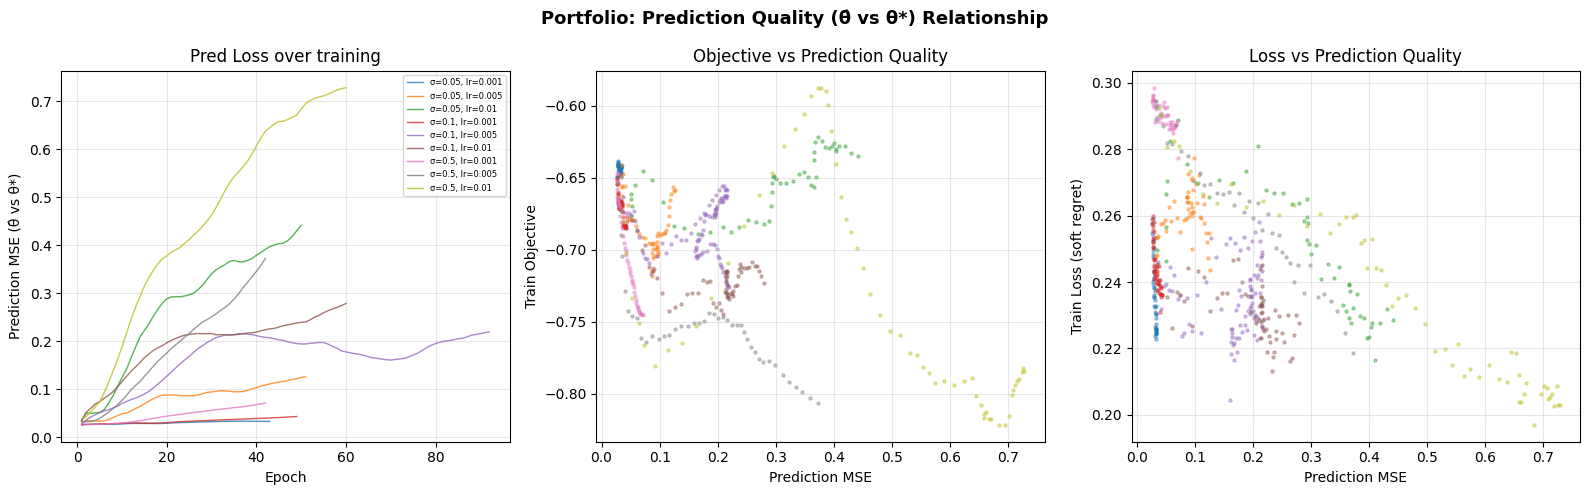

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for sigma_tag, sigma_val in SIGMAS.items():
    for lr_tag, lr_val in LRS.items():
        prefix = f"sd1_s{sigma_tag}_{lr_tag}"
        tdf, vdf = read_traces(prefix)
        if tdf is None:
            continue
        label = f"σ={sigma_val}, lr={lr_val}"
        
        # Panel 1: pred_loss over time
        axes[0].plot(tdf["epoch_num"], tdf["pred_loss"], label=label, linewidth=1, alpha=0.8)
        # Panel 2: obj vs pred_loss (scatter)
        axes[1].scatter(tdf["pred_loss"], tdf["obj"], s=5, alpha=0.4, label=label)
        # Panel 3: loss vs pred_loss (scatter)
        axes[2].scatter(tdf["pred_loss"], tdf["loss"], s=5, alpha=0.4, label=label)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Prediction MSE (θ̂ vs θ*)")
axes[0].set_title("Pred Loss over training")
axes[0].legend(fontsize=6)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Prediction MSE")
axes[1].set_ylabel("Train Objective")
axes[1].set_title("Objective vs Prediction Quality")
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel("Prediction MSE")
axes[2].set_ylabel("Train Loss (soft regret)")
axes[2].set_title("Loss vs Prediction Quality")
axes[2].grid(True, alpha=0.3)

fig.suptitle("Portfolio: Prediction Quality (θ̂ vs θ*) Relationship",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. σ dependence: larger σ → worse divergence?

With larger σ, the soft decision z̄ averages over a wider distribution of z(θ̂+σε).
This makes z̄ smoother and easier to optimize, but the gap between z̄ and z(θ̂) grows.
We'd expect larger σ → more divergence between soft regret (loss) and hard decision quality (obj).

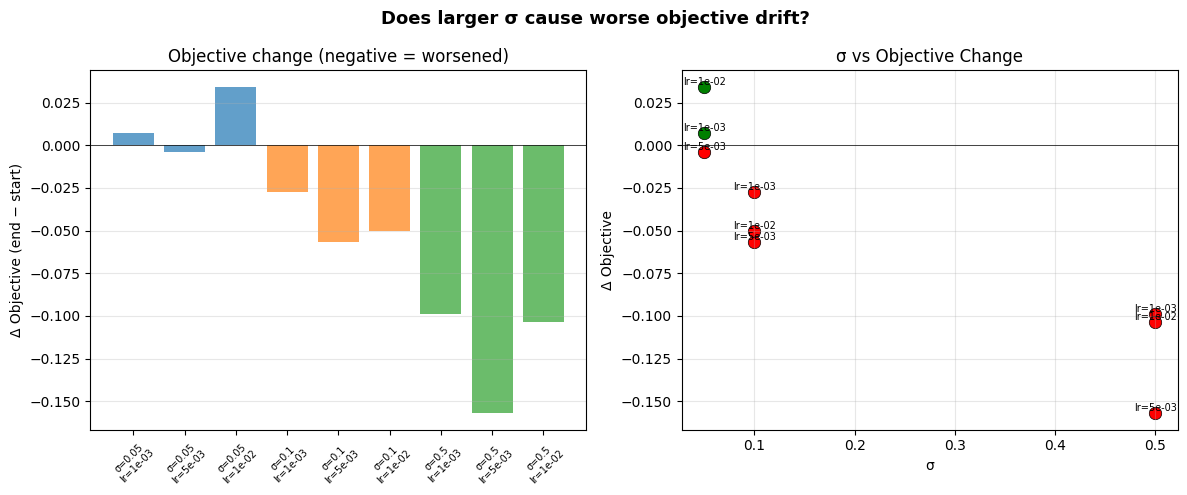

In [5]:
if len(summary) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Group by sigma
    for sigma_val, grp in summary.groupby("sigma"):
        axes[0].bar([f"σ={sigma_val}\nlr={r['lr']:.0e}" for _, r in grp.iterrows()],
                    grp["obj_delta"], alpha=0.7, label=f"σ={sigma_val}")
    axes[0].axhline(y=0, color="black", linewidth=0.5)
    axes[0].set_ylabel("Δ Objective (end − start)")
    axes[0].set_title("Objective change (negative = worsened)")
    axes[0].tick_params(axis="x", rotation=45, labelsize=7)
    axes[0].grid(True, alpha=0.3, axis="y")

    # Scatter: sigma vs obj_delta
    for _, row in summary.iterrows():
        axes[1].scatter(row["sigma"], row["obj_delta"],
                        s=80, c="red" if row["obj_delta"] < 0 else "green",
                        edgecolors="black", linewidth=0.5)
        axes[1].annotate(f"lr={row['lr']:.0e}", (row["sigma"], row["obj_delta"]),
                         fontsize=7, ha="center", va="bottom")
    axes[1].axhline(y=0, color="black", linewidth=0.5)
    axes[1].set_xlabel("σ")
    axes[1].set_ylabel("Δ Objective")
    axes[1].set_title("σ vs Objective Change")
    axes[1].grid(True, alpha=0.3)

    fig.suptitle("Does larger σ cause worse objective drift?",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 5. The mechanism: soft decision z̄ vs hard decision z(θ̂)

The DPO training loss is:

$$\mathcal{L} = |f(\theta^*, \bar{z}) - f(\theta^*, z^*)|$$

where $\bar{z} = \frac{1}{N}\sum_{n=1}^{N} z(\hat\theta + \sigma\epsilon_n)$.

Gradients flow through $\bar{z}$ via the Berthet Jacobian to update the prediction model.
The model learns to produce $\hat\theta$ such that *the average of nearby hard solutions*
$\bar{z}$ gives good objective — but the hard solution *at exactly* $\hat\theta$ may be bad.

**Intuition**: Consider a 1D portfolio with two assets. The solver outputs a corner solution
z(θ̂) ∈ {[1,0], [0,1]}. The soft decision z̄ ≈ [0.6, 0.4] can be anywhere on the simplex.
The model can learn θ̂ where z̄ is near the optimal portfolio, but z(θ̂) = [1,0] (a bad corner).

**This is the fundamental gap between continuous relaxation quality and discrete decision quality
in DPO.**

## Possible remedies

1. **Anneal σ → 0**: As σ shrinks, z̄ → z(θ̂), closing the gap. But too-fast annealing
   causes vanishing gradients.
2. **Add prediction loss regularization**: Loss = soft_regret + λ·MSE(θ̂, θ\*). This keeps
   θ̂ near θ\*, which keeps z(θ̂) near z(θ\*).
3. **Use the objective directly as loss**: Loss = −f(θ\*, z̄) instead of |f − f\*|. Same
   gradient (for a max problem), but avoids possible issues with the abs().
4. **Lower σ**: Our data should show that smaller σ → less divergence, since z̄ stays
   closer to z(θ̂).

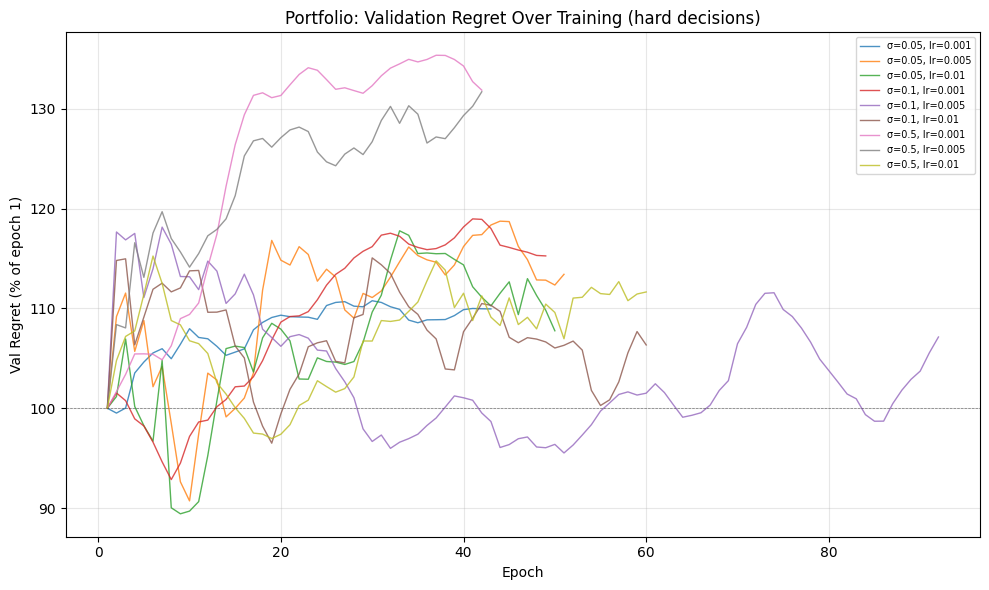


Val regret: start vs best vs end
          config  val_regret_start  val_regret_best  val_regret_end
σ=0.05, lr=0.001          0.330387         0.328793        0.363245
σ=0.05, lr=0.005          0.353135         0.320383        0.400499
 σ=0.05, lr=0.01          0.375944         0.336216        0.405113
 σ=0.1, lr=0.001          0.338392         0.314225        0.390013
 σ=0.1, lr=0.005          0.356027         0.340088        0.381431
  σ=0.1, lr=0.01          0.385499         0.372019        0.409940
 σ=0.5, lr=0.001          0.329634         0.329634        0.434630
 σ=0.5, lr=0.005          0.376583         0.376583        0.495926
  σ=0.5, lr=0.01          0.413808         0.401258        0.461998


In [6]:
# Compare: does val regret still improve even though obj worsens?
# val regret uses hard decisions, so if it worsens too, DPO truly fails here.

if len(summary) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    for sigma_tag, sigma_val in SIGMAS.items():
        for lr_tag, lr_val in LRS.items():
            prefix = f"sd1_s{sigma_tag}_{lr_tag}"
            tdf, vdf = read_traces(prefix)
            if vdf is None:
                continue
            label = f"σ={sigma_val}, lr={lr_val}"
            # Normalize val regret to percentage of initial
            regret_pct = 100 * vdf["eval"] / vdf["eval"].iloc[0]
            ax.plot(vdf["epoch_num"], regret_pct, label=label, linewidth=1, alpha=0.8)

    ax.axhline(y=100, color="black", linewidth=0.5, linestyle="--", alpha=0.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Regret (% of epoch 1)")
    ax.set_title("Portfolio: Validation Regret Over Training (hard decisions)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
    
    print("\nVal regret: start vs best vs end")
    print("=" * 80)
    print(summary[["config", "val_regret_start", "val_regret_best", "val_regret_end"]].to_string(index=False))

## 6. Correlation matrix: all logged quantities

For the best config (σ=0.05, lr=1e-3), compute epoch-to-epoch correlations
between all columns to see which metrics move together.

Best config: σ=0.1, lr=0.001


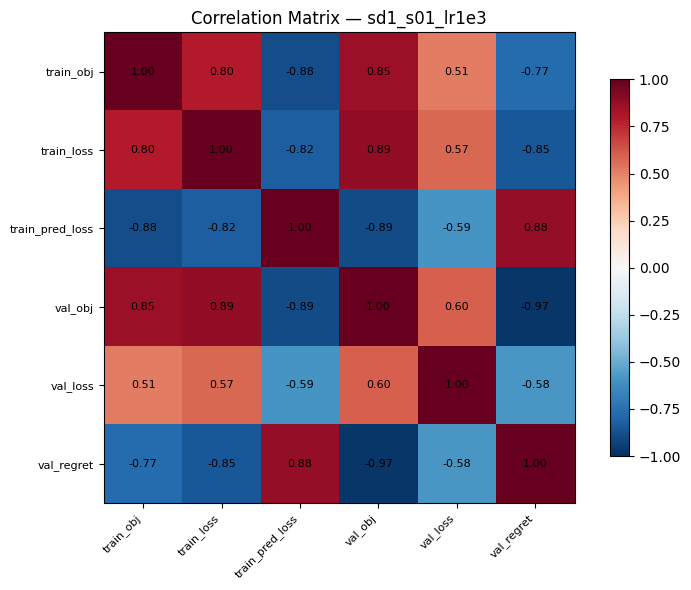

In [7]:
# Pick the config with best val regret
best_row = summary.loc[summary["val_regret_best"].idxmin()]
best_sigma = best_row["sigma"]
best_lr = best_row["lr"]
print(f"Best config: σ={best_sigma}, lr={best_lr}")

# Find matching prefix
stag = {v: k for k, v in SIGMAS.items()}[best_sigma]
ltag = {v: k for k, v in LRS.items()}[best_lr]
prefix = f"sd1_s{stag}_{ltag}"

tdf, vdf = read_traces(prefix)

# Merge train and val by epoch
merged = tdf[["epoch_num", "obj", "loss", "pred_loss"]].rename(
    columns={"obj": "train_obj", "loss": "train_loss", "pred_loss": "train_pred_loss"}
)
vmerge = vdf[["epoch_num", "obj", "loss", "eval"]].rename(
    columns={"obj": "val_obj", "loss": "val_loss", "eval": "val_regret"}
)
merged = merged.merge(vmerge, on="epoch_num", how="inner")

# Correlation matrix
corr_cols = ["train_obj", "train_loss", "train_pred_loss", "val_obj", "val_loss", "val_regret"]
corr = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols, fontsize=8)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f"Correlation Matrix — {prefix}", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Comparison with other problems

Does this same pattern (obj worsening) happen for problems where the solver minimizes
rather than maximizes? For minimization problems, obj should increase (worsen) if the
same divergence occurs.

In [8]:
OTHER_PROBLEMS = {
    "knapsack-gen": "knapsack",
    "cubic-gen": "cubic",
    "bipartitematching-cora": "bipartite",
    "knapsack-energy": "knapsack-energy",
}

comparison_rows = []
for data_name, short_name in OTHER_PROBLEMS.items():
    for sigma_tag, sigma_val in SIGMAS.items():
        for lr_tag, lr_val in LRS.items():
            prefix = f"sd1_s{sigma_tag}_{lr_tag}"
            tcsv = f"saved_records/{data_name}/perturb/{prefix}/train_logs.csv"
            vcsv = f"saved_records/{data_name}/perturb/{prefix}/val_logs.csv"
            if not os.path.exists(tcsv):
                continue
            tdf = pd.read_csv(tcsv)
            vdf = pd.read_csv(vcsv)
            if len(tdf) < 2:
                continue
            comparison_rows.append({
                "problem": short_name,
                "sigma": sigma_val,
                "lr": lr_val,
                "obj_start": tdf["obj"].iloc[0],
                "obj_end": tdf["obj"].iloc[-1],
                "obj_delta": tdf["obj"].iloc[-1] - tdf["obj"].iloc[0],
                "loss_delta": tdf["loss"].iloc[-1] - tdf["loss"].iloc[0],
                "pred_loss_delta": tdf["pred_loss"].iloc[-1] - tdf["pred_loss"].iloc[0],
            })

if comparison_rows:
    comp_df = pd.DataFrame(comparison_rows)
    
    # Summary per problem: how often does obj worsen?
    print("Objective drift across problems")
    print("=" * 80)
    for prob in comp_df["problem"].unique():
        pdata = comp_df[comp_df["problem"] == prob]
        n_worse = (pdata["obj_delta"] < 0).sum()  # obj goes down (worse for max, better for min)
        n_better = (pdata["obj_delta"] > 0).sum()
        mean_delta = pdata["obj_delta"].mean()
        mean_pred_delta = pdata["pred_loss_delta"].mean()
        print(f"  {prob:20s}: Δobj<0 in {n_worse}/{len(pdata)}, "
              f"Δobj>0 in {n_better}/{len(pdata)}, "
              f"mean Δobj={mean_delta:+.4f}, mean Δpred_loss={mean_pred_delta:+.4f}")
    
    # Portfolio for comparison
    port_worse = (summary["obj_delta"] < 0).sum()
    port_mean = summary["obj_delta"].mean()
    port_pred = (summary["pred_loss_end"] - summary["pred_loss_start"]).mean()
    print(f"  {'portfolio':20s}: Δobj<0 in {port_worse}/{len(summary)}, "
          f"mean Δobj={port_mean:+.4f}, mean Δpred_loss={port_pred:+.4f}")
else:
    print("No comparison data available yet.")

Objective drift across problems
  knapsack            : Δobj<0 in 0/9, Δobj>0 in 9/9, mean Δobj=+7.4944, mean Δpred_loss=-2.2607
  cubic               : Δobj<0 in 1/9, Δobj>0 in 8/9, mean Δobj=+8.4156, mean Δpred_loss=+1.8710
  bipartite           : Δobj<0 in 0/9, Δobj>0 in 9/9, mean Δobj=+1.3736, mean Δpred_loss=-0.1102
  knapsack-energy     : Δobj<0 in 0/9, Δobj>0 in 9/9, mean Δobj=+185.6180, mean Δpred_loss=-94.9081
  portfolio           : Δobj<0 in 7/9, mean Δobj=-0.0508, mean Δpred_loss=+0.2263


## Summary of Findings

**TODO** — Fill in after running the cells above:

1. **obj vs loss divergence**: (describe pattern)
2. **pred_loss correlation**: (does θ̂ drift from θ*?)
3. **σ dependence**: (larger σ → more divergence?)
4. **val regret**: (does it improve, or also worsen?)
5. **Other problems**: (portfolio-specific or universal?)
6. **Recommendation**: (what to try next)